In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version :", tf.__version__)
print("Keras version :", keras.__version__)

TensorFlow version : 2.21.0
Keras version : 3.15.0


In [2]:
from pathlib import Path
import os

In [3]:
# Configuration des chemins

DATA_DIR = DATA_DIR = Path("../data/raw/images")

# Extensions d'images valides
EXTENSIONS_VALIDES = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

# Vérification des classes disponibles
classes = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])

print(f"Nombre de classes : {len(classes)}")
print(f"Classes détectées : {classes}")

# Comptage des images par classe
print("\nNombre d'images par classe :")
total = 0
for classe in classes:
    chemin = os.path.join(DATA_DIR, classe)
    nb_images = len([
        f for f in os.listdir(chemin)
        if os.path.splitext(f)[1] in EXTENSIONS_VALIDES
    ])
    total += nb_images
    print(f"  {classe} : {nb_images} images")

print(f"\nTotal : {total} images")

Nombre de classes : 6
Classes détectées : ['Kedjenou', 'alloco', 'foutou', 'mafe', 'thieboudiene', 'yassa-poulet']

Nombre d'images par classe :
  Kedjenou : 100 images
  alloco : 100 images
  foutou : 100 images
  mafe : 100 images
  thieboudiene : 100 images
  yassa-poulet : 100 images

Total : 600 images


In [4]:
# Chargement des données avec Keras
IMG_SIZE   = (224, 224)  # Taille requise par EfficientNet-B0
BATCH_SIZE = 32          # Nombre d'images traitées à la fois
SEED       = 42          # Pour avoir des résultats reproductibles

# 80% des images → entraînement
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 20% des images → validation
val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Classes : {class_names}")
print(f"Images d'entraînement : {len(train_ds) * BATCH_SIZE}")
print(f"Images de validation  : {len(val_ds) * BATCH_SIZE}")

Found 600 files belonging to 6 classes.
Using 480 files for training.
Found 600 files belonging to 6 classes.
Using 120 files for validation.
Classes : ['Kedjenou', 'alloco', 'foutou', 'mafe', 'thieboudiene', 'yassa-poulet']
Images d'entraînement : 480
Images de validation  : 128


In [5]:
#  Augmentation légère (appliquée uniquement au train)
from tensorflow.keras import layers, models
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [8]:
# construction du modèle MobileNet_V2
from tensorflow.keras.applications import MobileNetV2
base_model = MobileNetV2(
        weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3)
    )

base_model.trainable = False  # backbone gelé pour la phase 1
 
inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
 
model = models.Model(inputs, outputs, name="MobileNetV2")
model.summary()

Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
 # PHASE 1 : entraînement de la tête (backbone gelé)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
 
# Callbacks pour optimiser l'entraînement
callbacks = [
    # S'arrête si la validation ne s'améliore plus après 5 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    # Réduit le learning rate si stagnation
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]
 
print("\n=== Phase 1 : entraînement de la tête ===")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)
print("\nEntraînement terminé !")


=== Phase 1 : entraînement de la tête ===
Epoch 1/20


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


15/15 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.2833 - loss: 1.8316 - val_accuracy: 0.3583 - val_loss: 1.5225 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.4833 - loss: 1.3621 - val_accuracy: 0.5750 - val_loss: 1.1002 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.6333 - loss: 1.0151 - val_accuracy: 0.7083 - val_loss: 0.9183 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.6708 - loss: 0.8478 - val_accuracy: 0.7250 - val_loss: 0.8220 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7604 - loss: 0.7353 - val_accuracy: 0.7667 - val_loss: 0.7259 - learning_rate: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7646 - loss: 0.6634 - val_accuracy: 0.8083 - val_loss: 0.7159 - learning_rate: 0.0010
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.7667 - loss: 0.6287 - val_accuracy: 0.8167 - va

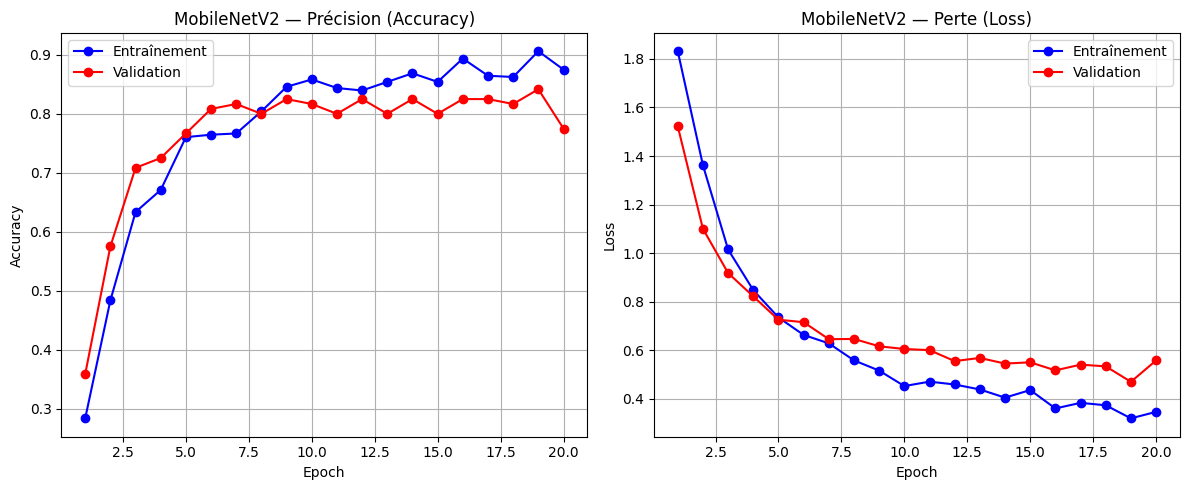

Courbes sauvegardées !


In [10]:
# Visualisation des courbes d'entraînement ---
import matplotlib.pyplot as plt
 
acc = history.history["accuracy"] 
val_acc = history.history["val_accuracy"] 
loss = history.history["loss"] 
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
 
plt.figure(figsize=(12, 5))
 
# Courbe Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, "b-o", label="Entraînement")
plt.plot(epochs, val_acc, "r-o", label="Validation")
plt.title("MobileNetV2 — Précision (Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
 
# Courbe Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "b-o", label="Entraînement")
plt.plot(epochs, val_loss, "r-o", label="Validation")
plt.title("MobileNetV2 — Perte (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
 
plt.tight_layout()
plt.savefig("courbes_MobileNetV2.png", dpi=150)
plt.show()
print("Courbes sauvegardées !")

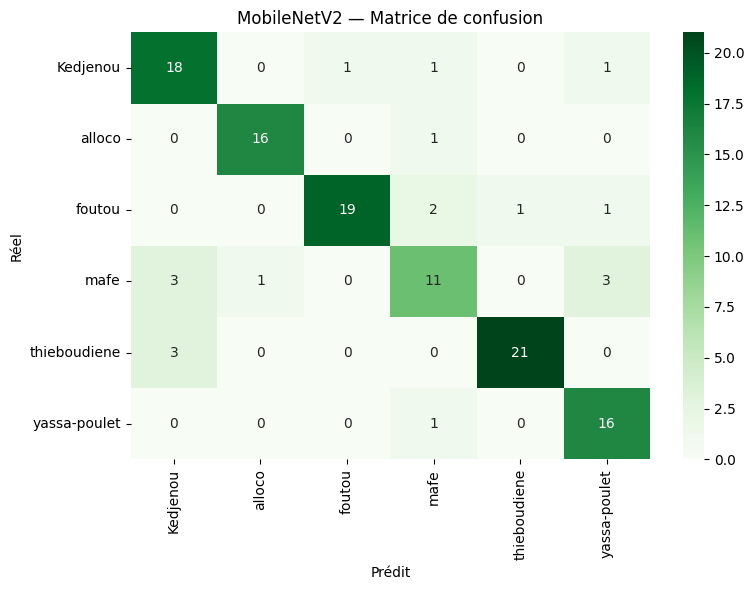


Rapport détaillé — MobileNetV2 :
              precision    recall  f1-score   support

    Kedjenou       0.75      0.86      0.80        21
      alloco       0.94      0.94      0.94        17
      foutou       0.95      0.83      0.88        23
        mafe       0.69      0.61      0.65        18
thieboudiene       0.95      0.88      0.91        24
yassa-poulet       0.76      0.94      0.84        17

    accuracy                           0.84       120
   macro avg       0.84      0.84      0.84       120
weighted avg       0.85      0.84      0.84       120



In [11]:
# Matrice de confusion 
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
 
# Prédictions sur la validation
y_pred = []
y_true = []
 
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())
 
# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
 
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Greens")
plt.title("MobileNetV2 — Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig("matrice_confusion_MobileNetV2.png", dpi=150)
plt.show()
 
print("\nRapport détaillé — MobileNetV2 :")
print(classification_report(y_true, y_pred, target_names=class_names))
 

In [12]:
# Sauvegarde du modèle
 
# Création_du_dossier models 
os.makedirs("models", exist_ok=True)
 
# Sauvegarder le modèle au format Keras
model.save("models/mobilenetv2_final.keras")
 
print("Modèle sauvegardé dans models/mobilenetv2_final.keras ✅")
print(f"Précision finale : {max(val_acc):.2%}")

Modèle sauvegardé dans models/mobilenetv2_final.keras ✅
Précision finale : 84.17%
